# **Determinación de las variables que influyen más en el éxito reproductivo (Selección de Factores)**

### **Por:**

*   Yasmin Judith Florez Zabala
*   John Jairo Sevilla Rodriguez
*   Yulexa Andrea Aragón Lemus

### **Ciclo de vida**
1. Preparación de Datos
2. Análisis de Correlaciones

In [ ]:
# Se importan las librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

## **1. Preparación de Datos**

In [ ]:
# Se importa la librería para leer archivos .arff
from scipy.io import arff

# Se lee el archivo ARFF
data, meta = arff.loadarff('sabana_hembras_porcinas_procesado.arff')

# Se convierte a DataFrame
df = pd.DataFrame(data)

# Se decodifica todas las columnas de tipo objeto
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode('utf-8')

# Se muestran las 5 primeras filas
df.head()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS,PARTO_EXITOSO
0,6.0,14.000,2.0,0.0,EXITOSO
1,7.0,14.000,5.0,0.0,NO_EXITOSO
2,8.0,13.750,6.0,0.0,EXITOSO
3,9.0,14.000,6.0,0.0,NO_EXITOSO
4,10.0,13.666,6.0,0.0,EXITOSO


In [ ]:
# Se conocen los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350981 entries, 0 to 350980
Data columns (total 5 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   NUMERO_PARTO               350981 non-null  float64
 1   PROMEDIO_VIVOS_ANTERIORES  350981 non-null  float64
 2   TOTAL_MUERTOS_ANTERIORES   350981 non-null  float64
 3   RETORNOS_ACUMULADOS        350981 non-null  float64
 4   PARTO_EXITOSO              350981 non-null  object 
dtypes: float64(4), object(1)
memory usage: 13.4+ MB


In [ ]:
# Se corrigen los tipos de datos
df["PARTO_EXITOSO"] = df["PARTO_EXITOSO"].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350981 entries, 0 to 350980
Data columns (total 5 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   NUMERO_PARTO               350981 non-null  float64 
 1   PROMEDIO_VIVOS_ANTERIORES  350981 non-null  float64 
 2   TOTAL_MUERTOS_ANTERIORES   350981 non-null  float64 
 3   RETORNOS_ACUMULADOS        350981 non-null  float64 
 4   PARTO_EXITOSO              350981 non-null  category
dtypes: category(1), float64(4)
memory usage: 11.0 MB


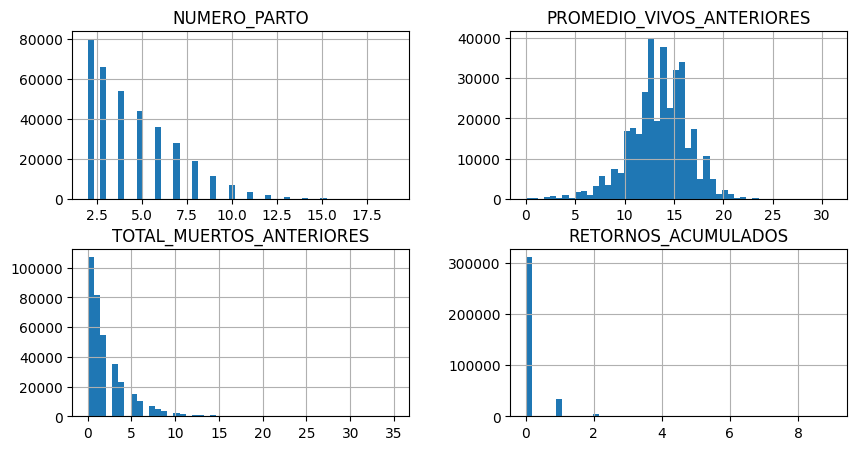

In [ ]:
# Histogramas de las variables numéricas
df.hist(bins=50, figsize=(10,5))
plt.show()

<Axes: ylabel='count'>

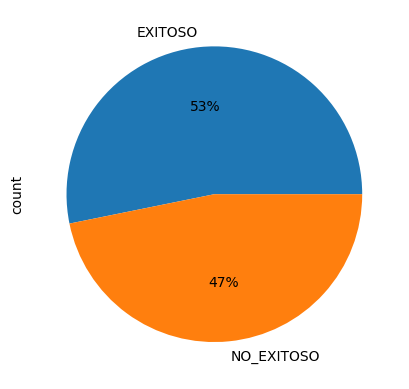

In [ ]:
# Descripción de la variable categórica
df['PARTO_EXITOSO'].value_counts().plot(kind='pie', autopct='%.0f%%')

In [ ]:
#Se crean dummies para la variable categórica
df = pd.get_dummies(df, columns=['PARTO_EXITOSO'], drop_first=True, dtype=int)
df.head()

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS,PARTO_EXITOSO_NO_EXITOSO
0,6.0,14.000,2.0,0.0,0
1,7.0,14.000,5.0,0.0,1
2,8.0,13.750,6.0,0.0,0
3,9.0,14.000,6.0,0.0,1
4,10.0,13.666,6.0,0.0,0


## **2. Análisis de Correlaciones**

In [ ]:
# Se calcula la matriz de correlación
correlaciones = df.corr()
correlaciones

,NUMERO_PARTO,PROMEDIO_VIVOS_ANTERIORES,TOTAL_MUERTOS_ANTERIORES,RETORNOS_ACUMULADOS,PARTO_EXITOSO_NO_EXITOSO
NUMERO_PARTO,1.000000,-0.059755,0.447029,0.092924,0.152720
PROMEDIO_VIVOS_ANTERIORES,-0.059755,1.000000,-0.014740,-0.065662,-0.229399
TOTAL_MUERTOS_ANTERIORES,0.447029,-0.014740,1.000000,0.073975,0.057670
RETORNOS_ACUMULADOS,0.092924,-0.065662,0.073975,1.000000,0.059258
PARTO_EXITOSO_NO_EXITOSO,0.152720,-0.229399,0.057670,0.059258,1.000000


In [ ]:
# Se extraen las correlaciones de todas las variables respecto a la variable de interés: 'PARTO_EXITOSO_NO_EXITOSO'
cor_variable_interes = correlaciones.loc['PARTO_EXITOSO_NO_EXITOSO']
cor_variable_interes

,PARTO_EXITOSO_NO_EXITOSO
NUMERO_PARTO,0.152720
PROMEDIO_VIVOS_ANTERIORES,-0.229399
TOTAL_MUERTOS_ANTERIORES,0.057670
RETORNOS_ACUMULADOS,0.059258
PARTO_EXITOSO_NO_EXITOSO,1.000000


<BarContainer object of 5 artists>

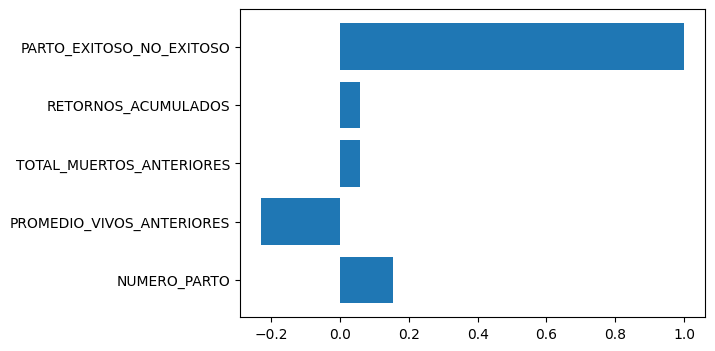

In [ ]:
# Se crea una figura para visualizar gráficamente las correlaciones de cada variable con la variable objetivo
plt.figure(figsize=(6, 4))

# Se construye un gráfico de barras horizontales
plt.barh(y=df.columns, width=cor_variable_interes)